# Grain Core and Boundary Zone Detection

This notebook demonstrates how to detect grain cores and boundary zones using binary erosion with a minimum core size constraint.
## Overview

This notebook explores three methods for detecting grain cores and boundary zones in polycrystalline microstructures:

1. **`use_min_core_size`** - Ensures grain cores meet a minimum size threshold during erosion
2. **`simple`** - Standard binary erosion without size constraints
3. **`thresholded`** - Controls boundary zone thickness via a threshold parameter

Each method uses the `introduce_boundary_zones()` function from `upxo.pxtalops.grain_boundary_zones` to process labeled grain images (LGI) and identify:
- **Grain cores**: Interior regions after erosion
- **Boundary zones**: Pixels removed during erosion (grain boundaries)

The workflow:
- Initialize a 2D Monte-Carlo grain structure (`mcgs`)
- Simulate grain growth and detect grains
- Characterize grain morphology (area, aspect ratio, solidity, etc.)
- Apply different boundary zone detection methods
- Visualize results to compare core/boundary delineation

**Key parameters**:
- `niterations`: Number of erosion cycles
- `structure_nx`, `structure_ny`: Structuring element size (connectivity)
- `min_core_size`: Minimum pixel count for valid cores (method 1)
- `threshold_bz_thickness`: Boundary zone thickness limit (method 3)

In [1]:
# Import libraries
from upxo.ggrowth.mcgs import mcgs
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from scipy.ndimage import binary_erosion
from upxo.pxtalops.grain_boundary_zones import introduce_boundary_zones

In [49]:
# Initialize and simulate grain structure
pxt = mcgs(input_dashboard='C:\\Development\\UPXO\\upxo_library\\src\\upxo\\interfaces\\user_inputs\\input_dashboard_profiling_alg202a.xls')
pxt.simulate()
pxt.detect_grains()
pxt.char_morph_2d(bbox=True, M=list(pxt.gs.keys())[3:], bbox_ex=True, 
                  area=True, aspect_ratio=True, solidity=True, 
                  circularity=True, eccentricity=True, euler_number=True,
                  append=False, saa=True, throw=False, 
                  char_grain_positions=False, find_neigh=False, 
                  char_gb=False, make_skim_prop=True, 
                  get_grain_coords=False)

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs\input_dashboard_profiling_alg202a.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 100.0, 1.0
     ymin, ymax, yinc: 0.0, 25.0, 1.0
     zmin, zmax, zinc: 0.0, 1000.0, 1.0
     No. of states: 5
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
|--------------- MC SIM RUN COMPLETED on: ALG200---------------|
Using scikit-image for grain identification
MC state = 1:  Num grains = 66
MC state = 2:  Num grains = 46
MC state = 3:  Num grains = 53
MC state = 4:  Num grains = 66
MC state = 5:  Num grains = 70
Temporal

In [50]:
gsid = 3

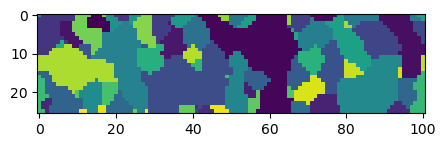

In [51]:
plt.figure(figsize=(5, 5), dpi=100)
plt.imshow(pxt.gs[gsid].lgi, cmap='viridis')

## Method 1: Minimum Core Size Constraint

The `use_min_core_size` method ensures that grain cores maintain a minimum size (in pixels) during binary erosion. This prevents small grains from being completely eroded away, preserving their structural identity.

**Parameters**:
- `niterations=1`: Single erosion pass
- `min_core_size=1`: Retain cores with ≥1 pixel
- `structure_nx=3, structure_ny=3`: 3×3 structuring element (8-connectivity)

This approach is useful when analyzing microstructures with grains of varying sizes, ensuring that even small grains are represented in the core map.

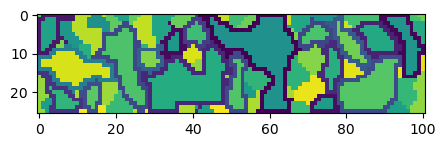

In [52]:
lgi = introduce_boundary_zones(pxt.gs[gsid], fids=[], niterations=1, method='use_min_core_size',
                              min_core_size=1,
                              structure_nx=3, structure_ny=3,
                              see_plot=True, figure_size=(5, 5), figure_dpi=100)

## Method 2: Simple Binary Erosion

The `simple` method applies standard binary erosion without any size constraints. Each erosion iteration removes pixels from grain boundaries uniformly across all grains, regardless of their size.

**Parameters**:
- `niterations=1`: Single erosion pass
- `structure_nx=3, structure_ny=3`: 3×3 structuring element (8-connectivity)

This approach is straightforward but may completely erode small grains, leaving them without core representation. It's most effective for microstructures with uniformly sized grains where boundary zone thickness needs to be consistent across all features.

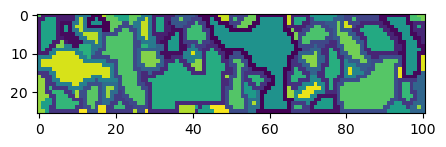

In [61]:
lgi = introduce_boundary_zones(pxt.gs[gsid], fids=[], niterations=1, method='simple',
                              structure_nx=3, structure_ny=3,
                              see_plot=True, figure_size=(5, 5), figure_dpi=100)

## Method 3: Thresholded Boundary Zone

The `thresholded` method controls boundary zone thickness by limiting erosion to a specified maximum thickness. Unlike simple erosion, this method tracks the cumulative erosion depth and stops removing pixels once the boundary zone reaches the desired thickness.

**Parameters**:
- `niterations=2`: Multiple erosion passes allowed
- `threshold_bz_thickness=1`: Maximum boundary zone thickness (in pixels)
- `structure_nx=3, structure_ny=3`: 3×3 structuring element (8-connectivity)

This approach provides precise control over boundary zone dimensions, making it ideal when a specific boundary zone width is required for mechanical or physical property analysis. The method prevents over-erosion by monitoring the distance from the original grain boundary, ensuring consistent boundary zone thickness across all grains regardless of their size or shape.

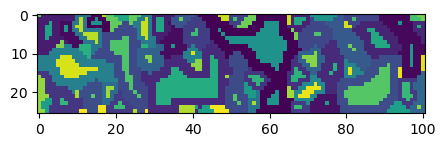

In [54]:
lgi = introduce_boundary_zones(pxt.gs[gsid], fids=[], niterations=2, method='thresholded',
                               threshold_bz_thickness=1,
                               structure_nx=3, structure_ny=3,
                               see_plot=True, figure_size=(5, 5), figure_dpi=100)

### Plotting seperately

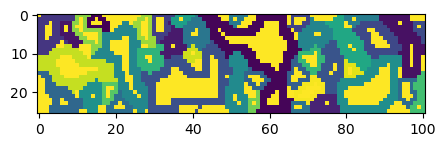

In [ ]:
plt.figure(figsize=(5, 5), dpi=100)
plt.imshow(lgi, cmap='viridis')